In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv(r"student_success_cleaned.csv")

In [36]:
df.head()

,student_id,name,gender,course,semester,attendance,internal_marks,assignment_completion,previous_gpa,failed_subjects,study_hours,previous_semester_marks,practical_marks,class_participation,risk_level
0,STU0001,Aryan Joshi,Male,BBA,1,52.0,66.9,100.0,8.44,1,1.9,60.6,46.9,61.5,High
1,STU0002,Rohan Khan,Male,BSc IT,1,82.9,50.7,64.2,8.65,0,3.5,75.1,63.2,64.8,Medium
2,STU0003,Diya Deshmukh,Female,BSc CS,3,91.4,36.5,98.9,9.61,0,2.4,78.7,67.5,64.4,Medium
3,STU0004,Aryan Verma,Female,BSc CS,2,100.0,67.8,95.0,6.05,0,2.8,78.5,84.0,66.8,Medium
4,STU0005,Varun Pawar,Female,BCom,6,54.0,78.5,54.0,5.72,0,2.9,66.8,51.8,48.3,High


In [37]:
df.shape

(2000, 15)

### **Separate X and y**

In [38]:
features = [
    "attendance",
    "internal_marks",
    "assignment_completion",
    "previous_gpa",
    "failed_subjects",
    "study_hours",
    "previous_semester_marks",
    "practical_marks",
    "class_participation"
]

X = df[features]

In [39]:
y = df["risk_level"]

In [40]:
y.value_counts()

risk_level
High      1600
Medium     384
Low         16
Name: count, dtype: int64

#### **covert risk_level_into_numbers**

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['High' 'Low' 'Medium']


In [42]:
print(y_encoded[:20])

[0 2 2 2 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 0]


#### **Split the dataset**

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [44]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1600, 9)
Testing: (400, 9)


### **Logistic Regression**

In [45]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
y_pred_lr = logistic_model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.88


In [48]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.91      0.95      0.93       320
         Low       0.00      0.00      0.00         3
      Medium       0.72      0.61      0.66        77

    accuracy                           0.88       400
   macro avg       0.54      0.52      0.53       400
weighted avg       0.87      0.88      0.87       400



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### **Decision Tree**

In [49]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

In [50]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.84


In [51]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.88      0.94      0.91       320
         Low       0.00      0.00      0.00         3
      Medium       0.62      0.45      0.53        77

    accuracy                           0.84       400
   macro avg       0.50      0.47      0.48       400
weighted avg       0.82      0.84      0.83       400



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### **Random Forest**

In [52]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

In [53]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.85


In [54]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.89      0.93      0.91       320
         Low       0.00      0.00      0.00         3
      Medium       0.64      0.53      0.58        77

    accuracy                           0.85       400
   macro avg       0.51      0.49      0.50       400
weighted avg       0.84      0.85      0.84       400



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### **Compare all Three Models**

In [63]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.88
1,Decision Tree,0.84
2,Random Forest,0.85


### **Confusion Matrix**

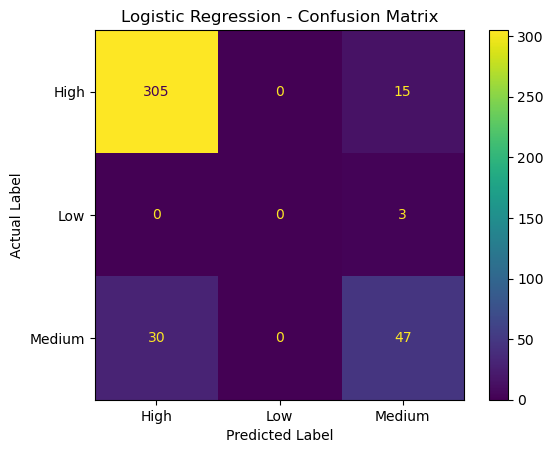

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=label_encoder.classes_
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### **Save the model**

In [65]:
import joblib

joblib.dump(random_forest, "risk_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(features, "features.pkl")

['features.pkl']